In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker 
import pickle
import re, sys
import pymongo
import sncosmo
from scipy.stats.distributions import chi2
from astropy.table import Table


In [2]:
# Depending on whether the library was added or not, you might have to manually add the base dir to the python path
sys.path.append('/Users/jnordin/github/ampelFeb25')

In [3]:
# We try to load the main loader class for warped templates
from warpTemplate import WarpfitTemplateLoader

What happens here:
1. Pick a SN from BTS together with the base class you which to use to fit against
2. Retrieve SN information: redshift and photometry.
3. Decide on how many templates you wish to fit to and (randmoly reterieve these). Can become many!
4. Fit SN to each of the selected templates
5. Print/plot results for the best fit

### 1. Pick a SN from BTS together with the base class you which to use to fit against

In [4]:
#snname = 'ZTF20abbbumr'
#snname = 'ZTF19aailltc'

# Bad cases from suleyman
#snname = 'ZTF19aanijpu' # Ic
#template_class_id = 8   # Ok, but not amazing w/o itself
#template_class_id = 4   # The same ...

#snname = 'ZTF19abcegvm' # Ic
#template_class_id = 8   # Ok, but not amazing
#template_class_id = 4   # The same ...

#snname = 'ZTF18abfcmjw' # Ib
#template_class_id = 0   # Ok, but not amazing
#template_class_id = 4   # The same ...

#snname = 'ZTF19aalouag' # Ib
#template_class_id = 0   # Ok, but not amazing
#template_class_id = 4   # The same ...


snname = 'ZTF21aamobbh'
#template_class_id = 0   # Ok, but not amazing
template_class_id = 4   # The same ...

# Only use good fits?
require_good_templatefit = False 
cutself = True # If set to False, it typically should fit perfectly



In [5]:
warpclasses = [
    'SN Ib', 'SN Ia-91bg', 'SN II', 'SN Ia-91T',
    'SN Ib/c', 'SN Ia-pec', 'SN IIP', 'SN Iax', 'SN Ic',
    'SLSN-II']

In [6]:
print('Fitting to templates of class', warpclasses[template_class_id])

Fitting to templates of class SN Ib/c


### 2. Retrieve SN information: redshift and photometry.

In [7]:
df_bts = pd.read_csv('/Users/jnordin/data/ztf/bts/bts_explorer_241122.csv')

In [8]:
sndict = df_bts.loc[df_bts['ZTFID']==snname,:].iloc[0]

In [9]:
print('looking at {} - type {}'.format(snname, sndict['type']))

looking at ZTF21aamobbh - type SN Ibn


In [10]:
client = pymongo.MongoClient()
db = client.bts_ipacfp_strictbase    # Only final lc. try bts_ipacfp_strictbase_full for all alerts

In [11]:
def get_db_table( name, database, tabulators ):
    """
    For ZTF name, get photopoints and then tables. 
    """
    from ampel.ztf.view.ZTFFPTabulator import ZTFFPTabulator
    from ampel.ztf.util.ZTFIdMapper import ZTFIdMapper

    # Name
    if isinstance(name, int):    
        # Assuming this is already a DB stock
        stock = int
    elif re.search('ZTF', name):
        stock = ZTFIdMapper.to_ampel_id(name)
    else:
        raise ValueError(f"Cannot parse {name}" )

    # Obtain photopoints
    dps = [dp for dp in database.t0.find({'stock':stock})]

    # Convert to table(s)
    ftables = [
        tabulator.get_flux_table(dps) for tabulator in tabulators
    ]
    if len(ftables)>1:
        raise NotImplementedError("Debug appending two tabulator tables.")
    return ftables.pop(0)
def get_ztftable_from_ampel(ztfid: str, dbhandle, include_sigma: float = 5., **kwarg) -> Table:
    """
    Given a ZTF name and a local AMPEL DB:
    - Retrieve available photometric data.
    - Reject outliers. 
    - Return an astropy table useful e.g. for sncosmo. 

    Parameters:
    - ztfid: str : ZTF name, e.g. ZTF18aaayemw
    - dbhandle: Database : AMPEL MongoDB handle
    - inclusion_sigma: float : Sigma threshold for outlier rejection.
    - kwarg: dict : Additional arguments added to table meta.

    tab = get_ztftable_from_ampel('ZTF22aaa', dbhandle, inclusion_sigma=5., z=0.03, type='SN Ia')

    """
    from ampel.ztf.view.ZTFFPTabulator import ZTFFPTabulator
    from ampel.ztf.util.ZTFIdMapper import ZTFIdMapper

    # Load photopoints from AMPEL DB
    tabulators = [
        ZTFFPTabulator(inclusion_sigma=include_sigma)
        ]
    tab = get_db_table(ztfid, database=dbhandle, tabulators=tabulators)
    tab.sort('time')

    tab.meta = {
            'object_id':ztfid,
            **kwarg
        }

    return tab

In [12]:
# Lets grab some data, starting with the target SN
# Warning: Note that the redshift and type also gets added to the meta information of the photometry table!
tab = get_ztftable_from_ampel( snname, db, 
                              redshift=float(sndict['redshift']), 
                              type = sndict['type'] )

In [13]:
tab

time,flux,fluxerr,band,zp,zpsys
float64,float64,float64,str4,int64,str2
2459267.7328819,210.9022351167764,19.267585744937822,ztfg,25,ab
2459267.7967477,172.48023770149467,17.27548936438502,ztfr,25,ab
2459269.7316898,572.3355529988397,23.85749695507501,ztfg,25,ab
2459269.7949884,471.4383877769693,22.166632408695445,ztfr,25,ab
2459271.7292361,666.230760859076,39.79961328401539,ztfg,25,ab
2459271.7558912,564.6038889919546,34.6945602870579,ztfr,25,ab
2459273.6715625,607.0140576182661,38.00211821338395,ztfg,25,ab
2459273.7327199,569.2819577187154,44.77500266302103,ztfr,25,ab
2459275.6891088,492.4073474232623,15.201148268562257,ztfg,25,ab


In [14]:
# Estimate significant detection
dps = sum( (np.abs(tab['flux']) / tab['fluxerr'])>5 )

In [15]:
dps

19

In [16]:
set(tab['band'])

{'ztfg', 'ztfr'}

### 3. Decide on how many templates you wish to fit to and (randmoly reterieve these).

In [17]:
# Parameters for fit template retrieval

if cutself:
    exclude_input = [snname] # Will reject any warptemplate containing any of these (either as sn or template basis)
else:
    exclude_input = []
# How to define templates?
# - How many templates per sn basis? 
#      * if 'all' it will return one copy of each template, 
#.     * if int it will return that many, drawn according to the template probability, 
#      * if -int it will return that many copies drawn from a uniform probabilitiy
#      Note: draws made with replacement, so multiple copies can be returned if int is larger than the available number of templates (often 3)
template_selection = 'all'
# - How many sn basis?
#.     * if 'all', take one of each
#.     * if an int, draw these randomly (with replacement)
#.     Note: how many templates are returned is decided by the above parameter.
snbasis_selection = 'all'



warpdir = '/Users/jnordin/data/models/sncosmo/warpmod'


In [18]:
warploader = WarpfitTemplateLoader(warpdir)

In [19]:
templates = warploader.get_templates(
    fitclass=warpclasses[template_class_id],
    exclude_input = exclude_input, 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    require_good_templatefit = require_good_templatefit,
    random_seed=42
)

2026-05-31 11:28:28,899 [INFO] Using random seed: 42
2026-05-31 11:28:28,899 [INFO] Loading warpcoeffs from /Users/jnordin/data/models/sncosmo/warpmod/warpcoeffs_SN Ibc_distinfo.pkl
2026-05-31 11:28:29,066 [INFO] 152 SN bases available after filtering
2026-05-31 11:28:44,451 [INFO] Returning 3163 templates


### 4. Fit SN to each of the selected templates

In [20]:
# Loop through templates, fit and plot the best...
bestmodel = None
for k, template in enumerate(templates):
    fitprop = ['t0', 'amplitude', 'hostebv']
    try:
        wresult, wfitted_model = sncosmo.fit_lc(
                        tab, template['model'],
                        fitprop,  # parameters of model to vary
                    )
    except RuntimeError:
        print(k,len(templates),template)
        print('fit failed')
        continue
    # Try to limit to models that use all the data
    if wresult['ndof']<(dps-len(fitprop)):
        print(k,len(templates),template)
        print('... datapoints rejected, skipping this for now.')
        continue
    # Check peak fit
    if (wresult['parameters'][1] < tab['time'].min()) or (wresult['parameters'][1] > tab['time'].max()):
        print(k,len(templates),template)
        print('...peak fit outside data time range')
        continue
    
    # Evaluate
    if wresult['success']:
        if bestmodel is None:
            bestmodel = [template,wfitted_model, wresult['chisq'] / wresult['ndof']]
        elif wresult['chisq'] / wresult['ndof'] < bestmodel[2]:
            bestmodel = [template,wfitted_model, wresult['chisq'] / wresult['ndof']]
#    sncosmo.plot_lc(tab, wfitted_model)

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/iminuit/util.py:177: IMinuitWarning: Assigned errors must be positive. Non-positive values are replaced by a heuristic.
  warnings.warn(


0 3163 {'basis_sn': 'ZTF21aarnjyd', 'model': <sncosmo.models.Model object at 0x12a614760>, 'template_prob': 1.0}
...peak fit outside data time range
2 3163 {'basis_sn': 'ZTF20abywsut', 'model': <sncosmo.models.Model object at 0x12b30f040>, 'template_prob': 0.02573934615632313}
...peak fit outside data time range
16 3163 {'basis_sn': 'ZTF20abywsut', 'model': <sncosmo.models.Model object at 0x12b337be0>, 'template_prob': 0.02573921562221567}
...peak fit outside data time range
28 3163 {'basis_sn': 'ZTF20abywsut', 'model': <sncosmo.models.Model object at 0x12e345600>, 'template_prob': 0.02573923257624374}
...peak fit outside data time range
32 3163 {'basis_sn': 'ZTF20abywsut', 'model': <sncosmo.models.Model object at 0x12e345e70>, 'template_prob': 0.025739099934772865}
...peak fit outside data time range
34 3163 {'basis_sn': 'ZTF20abywsut', 'model': <sncosmo.models.Model object at 0x12e3462f0>, 'template_prob': 0.025739123207929107}
...peak fit outside data time range
37 3163 {'basis_sn':

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:1997: RuntimeWarning: overflow encountered in power
  return extinction.apply(extinction.ccm89(wave, ebv * r_v, r_v), flux)
/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:1997: RuntimeWarning: overflow encountered in multiply
  return extinction.apply(extinction.ccm89(wave, ebv * r_v, r_v), flux)
/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:119: RuntimeWarning: overflow encountered in multiply
  return np.sum(wave * trans * f, axis=1) * dwave / HC_ERG_AA


68 3163 {'basis_sn': 'ZTF19aaxfcpq', 'model': <sncosmo.models.Model object at 0x15f6cda20>, 'template_prob': 0.02635491508855376}
fit failed
75 3163 {'basis_sn': 'ZTF19aaxfcpq', 'model': <sncosmo.models.Model object at 0x15f6ce5f0>, 'template_prob': 0.02635491508855376}
...peak fit outside data time range
77 3163 {'basis_sn': 'ZTF19aaxfcpq', 'model': <sncosmo.models.Model object at 0x15f6ce950>, 'template_prob': 0.026354915088553116}
...peak fit outside data time range
80 3163 {'basis_sn': 'ZTF21abrfvax', 'model': <sncosmo.models.Model object at 0x15f6ceef0>, 'template_prob': 0.3333333333333333}
...peak fit outside data time range
88 3163 {'basis_sn': 'ZTF20aajcdad', 'model': <sncosmo.models.Model object at 0x15f6cfc70>, 'template_prob': 0.05855814907034906}
...peak fit outside data time range
100 3163 {'basis_sn': 'ZTF19acmelor', 'model': <sncosmo.models.Model object at 0x15f6d93c0>, 'template_prob': 0.026193807372115574}
...peak fit outside data time range
102 3163 {'basis_sn': 'ZTF1

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

1242 3163 {'basis_sn': 'ZTF20aaerxne', 'model': <sncosmo.models.Model object at 0x15f8b1ed0>, 'template_prob': 0.08023028987379563}
fit failed
1243 3163 {'basis_sn': 'ZTF20aaerxne', 'model': <sncosmo.models.Model object at 0x15f8b2080>, 'template_prob': 0.08028236969394886}
fit failed
1246 3163 {'basis_sn': 'ZTF20aaerxne', 'model': <sncosmo.models.Model object at 0x15f8b26b0>, 'template_prob': 0.08003053012061813}
...peak fit outside data time range
1249 3163 {'basis_sn': 'ZTF20actekrw', 'model': <sncosmo.models.Model object at 0x15f8b2bc0>, 'template_prob': 0.010880112394125627}
...peak fit outside data time range
1251 3163 {'basis_sn': 'ZTF20actekrw', 'model': <sncosmo.models.Model object at 0x15f8b2f20>, 'template_prob': 0.028691348711728855}
...peak fit outside data time range
1253 3163 {'basis_sn': 'ZTF20actekrw', 'model': <sncosmo.models.Model object at 0x15f8b33d0>, 'template_prob': 0.06104282758171728}
...peak fit outside data time range
1254 3163 {'basis_sn': 'ZTF20actekrw', '

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:164: RuntimeWarning: overflow encountered in multiply
  fsum *= zpnorm


1340 3163 {'basis_sn': 'ZTF20abusrwm', 'model': <sncosmo.models.Model object at 0x15f8e1450>, 'template_prob': 0.03218981512455293}
fit failed
1342 3163 {'basis_sn': 'ZTF20abusrwm', 'model': <sncosmo.models.Model object at 0x15f8e17b0>, 'template_prob': 0.03276332317530295}
...peak fit outside data time range
1343 3163 {'basis_sn': 'ZTF20abusrwm', 'model': <sncosmo.models.Model object at 0x15f8e1ab0>, 'template_prob': 0.032308400924806586}
...peak fit outside data time range
1347 3163 {'basis_sn': 'ZTF20abusrwm', 'model': <sncosmo.models.Model object at 0x15f8e2170>, 'template_prob': 0.03273885818576906}
...peak fit outside data time range
1349 3163 {'basis_sn': 'ZTF20abusrwm', 'model': <sncosmo.models.Model object at 0x15f8e24d0>, 'template_prob': 0.010792754260853847}
...peak fit outside data time range
1350 3163 {'basis_sn': 'ZTF20abusrwm', 'model': <sncosmo.models.Model object at 0x15f8e2680>, 'template_prob': 0.03276326574714907}
...peak fit outside data time range
1351 3163 {'bas

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:119: RuntimeWarning: overflow encountered in divide
  return np.sum(wave * trans * f, axis=1) * dwave / HC_ERG_AA


3010 3163 {'basis_sn': 'ZTF20aaertpj', 'model': <sncosmo.models.Model object at 0x148e15390>, 'template_prob': 0.06569569176306389}
...peak fit outside data time range
3027 3163 {'basis_sn': 'ZTF21abrqrsz', 'model': <sncosmo.models.Model object at 0x148e17040>, 'template_prob': 0.027693777726802926}
...peak fit outside data time range
3028 3163 {'basis_sn': 'ZTF21abrqrsz', 'model': <sncosmo.models.Model object at 0x148e171f0>, 'template_prob': 0.02769380035311847}
...peak fit outside data time range
3030 3163 {'basis_sn': 'ZTF21abrqrsz', 'model': <sncosmo.models.Model object at 0x148e17550>, 'template_prob': 0.02768996739550312}
...peak fit outside data time range
3046 3163 {'basis_sn': 'ZTF21abrqrsz', 'model': <sncosmo.models.Model object at 0x148e61090>, 'template_prob': 0.02769205730366589}
...peak fit outside data time range
3049 3163 {'basis_sn': 'ZTF21abrqrsz', 'model': <sncosmo.models.Model object at 0x148e615a0>, 'template_prob': 0.02769379620542406}
...peak fit outside data ti

### 5. Print/plot results for the best fit

In [21]:
if (wresult['parameters'][1] < tab['time'].min()) or (wresult['parameters'][1] > tab['time'].max()):
    print('peak fit outside data time range')

In [22]:
bestmodel[0]

{'basis_sn': 'ZTF19aapfmki',
 'model': <sncosmo.models.Model at 0x15f90fdf0>,
 'template_prob': 0.98}

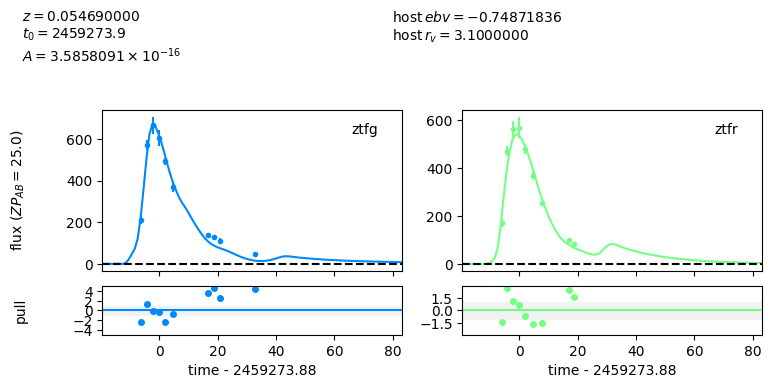

In [23]:
_ = sncosmo.plot_lc(tab, bestmodel[1])

In [24]:
sns = [temp["basis_sn"] for temp in templates]

In [25]:
'ZTF19aalouag' in set(sns)

False